In [1]:
import joblib
import tensorflow
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
base_path = '../models/'
bnb = joblib.load(base_path + 'bnb_best.joblib')
rfc = joblib.load(base_path + 'rfc_best.joblib')
svc = joblib.load(base_path + 'svc_best.joblib')
dnn = load_model(base_path + 'dnn_tf.keras')

C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator BernoulliNB from version 1.5.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.2 when using version 1.4.2. This might lea

In [3]:
input = "Hi this is a test"
tfidf = joblib.load('../data/tfidf.pkl')
X_new = tfidf.transform([input])


In [4]:
X_new.shape

(1, 53540)

In [5]:
tensorflow.__version__

'2.18.0'

In [6]:
X_new_new = tfidf.transform(["aaa aaplo aarp zuker hi this is test"])
print(X_new_new)

  (0, 53531)	0.47322154431626123
  (0, 46900)	0.2687297607869329
  (0, 20881)	0.45156522435065055
  (0, 8)	0.38725976437647064
  (0, 3)	0.3821691469385043
  (0, 0)	0.45156522435065055


In [7]:
bnb.predict(X_new)

C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [13]:
bnb.predict_proba(X_new).max(axis = 1)

array([1.])

In [8]:
rfc.predict(X_new)

C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [14]:
rfc.predict_proba(X_new).max(axis = 1)

C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0.62455202])

In [11]:
svc.predict(X_new.toarray())

array([1], dtype=int64)

In [15]:
svc.predict_proba(X_new.toarray()).max(axis = 1)

AttributeError: This 'SVC' has no attribute 'predict_proba'

In [7]:
dnn_conf = dnn.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


In [9]:
dnn_conf = dnn.predict(X_new_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [8]:
dnn_conf[0][0]

0.99743795

In [21]:
def make_dnn_label(conf):
    if conf > 0.5:
        return 1
    else:
        return 0

In [22]:
make_dnn_label(dnn_conf[0][0]) 

1

In [46]:
predictions = {}
predictions['label'] = ['Real' if x == 0 else 'Fake' for x in [bnb.predict(X_new)[0], rfc.predict(X_new)[0], svc.predict(X_new.toarray())[0], make_dnn_label(dnn_conf[0][0])]]
predictions['confidence'] = [bnb.predict_proba(X_new).max(axis = 1)[0], rfc.predict_proba(X_new).max(axis = 1)[0], 1.0, dnn_conf[0][0]]
models = ['Bernoulli Naive-Bayes', 'Random Forest', 'Support Vector Classifier', 'Deep Neural Network']

C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
C:\Users\kmbbm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [40]:
predictions

{'label': ['Fake', 'Fake', 'Fake', 'Fake'],
 'confidence': [0.9999999999996874, 0.6245520162549307, 1.0, 0.99743795]}

In [47]:
pred_df = pd.DataFrame(predictions, index = models)
pred_df

,label,confidence
Bertoulli Naive-Bayes,Fake,1.000000
Random Forest,Fake,0.624552
Support Vector Classifier,Fake,1.000000
Deep Neural Network,Fake,0.997438


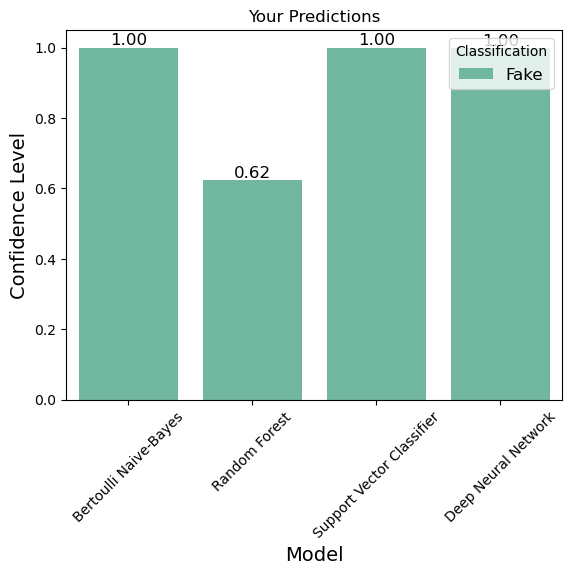

In [54]:
import random
import string

def generate_random_filename(extension='png', length=8):
    random_name = ''.join(random.choices(string.ascii_lowercase + string.digits, k=length))
    return f"{random_name}.{extension}"

ax = sns.barplot(data = pred_df, x = pred_df.index, y = 'confidence', hue = 'label', palette='BuGn')
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}',  # Format value to two decimal places
                (p.get_x() + p.get_width() / 2., p.get_height()),  
                ha='center', va='center', 
                fontsize=12, color='black',  
                xytext=(0, 5), textcoords='offset points') 
ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('Confidence Level', fontsize=14)
ax.legend(title='Classification', fontsize=12)
ax.set_title('Your Predictions')
plt.xticks(rotation=45)
random_filename = generate_random_filename()
filepath = f'./images/{random_filename}'
plt.savefig(filepath, format='png', dpi=300)
plt.show()

In [61]:
import json
def get_json(df, filepath):
    json_data = df.to_json(orient='index')
    print(type(json_data))
    json_dict = json.loads(json_data)
    comp_dict = {}
    comp_dict['models'] = json_dict
    comp_dict['filepath'] = random_filename
    updated_json_data = json.dumps(comp_dict, indent=4)
    return updated_json_data

json = get_json(pred_df, filepath)
print(json)

<class 'str'>
{
    "models": {
        "Bertoulli Naive-Bayes": {
            "label": "Fake",
            "confidence": 1.0
        },
        "Random Forest": {
            "label": "Fake",
            "confidence": 0.6245520163
        },
        "Support Vector Classifier": {
            "label": "Fake",
            "confidence": 1.0
        },
        "Deep Neural Network": {
            "label": "Fake",
            "confidence": 0.9974379539
        }
    },
    "filepath": "v2dhq1l6.png"
}
